In [1]:
import tqdm.notebook as tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
import time
from scipy.stats import wishart, multivariate_normal
import scipy.stats as stats

import plotly.express as px
import plotly.graph_objects as go

# Descriptive statistics

In [3]:
df = pd.read_excel(r"C:\School\THESIS\Cross-sectional\German_data_2004_names_of_columns.xls", header=0)


print('First 5 rows:')
display(df.head())
#print('Data types:')
#display(df.info())
print('Summary statistics:')
display(df.describe())
#print('Missing values:')
#display(df.isnull().sum())

First 5 rows:


,LOG_INCOME,EDUCATION,EDUCATION_FATHER_YEARS,DUMMY_SELFEMPLOYED,EXPERIENCE,EXPERIENCE_SQUARED,NON_GERMAN,MARRIED,UNEMPLOYMENT,WEALTH,...,INDUSTRY_AGRICULTURE,INDUSTRY_MANUFACTURING,INDUSTRY_HOTEL,INDUSTRY_FIRMSERVICES,INDUSTRY_FINANCIALSERVICES,INDUSTRY_CONSTRUCTION,INDUSTRY_TRANSPORT,INDUSTRY_HEALTH,INDUSTRY_CULTURE,INDUSTRY_RETAIL
0,3.158069,18.0,10,0,29.0,84.100000,0,1,2.0,6.907755,...,0,0,0,0,0,0,0,0,0,0
1,2.070267,10.5,9,0,24.6,60.516003,0,1,1.4,6.100745,...,0,0,0,0,0,0,0,0,0,0
2,2.767920,11.5,9,0,8.3,6.889000,0,0,0.0,6.871776,...,0,0,0,0,0,0,0,0,0,0
3,3.150978,15.0,13,0,7.6,5.776000,0,1,0.3,6.493996,...,0,0,0,0,0,0,1,0,0,0
4,2.666086,11.5,9,0,6.8,4.624000,0,1,0.0,4.431174,...,0,0,0,0,0,0,0,0,0,1


Summary statistics:


,LOG_INCOME,EDUCATION,EDUCATION_FATHER_YEARS,DUMMY_SELFEMPLOYED,EXPERIENCE,EXPERIENCE_SQUARED,NON_GERMAN,MARRIED,UNEMPLOYMENT,WEALTH,...,INDUSTRY_AGRICULTURE,INDUSTRY_MANUFACTURING,INDUSTRY_HOTEL,INDUSTRY_FIRMSERVICES,INDUSTRY_FINANCIALSERVICES,INDUSTRY_CONSTRUCTION,INDUSTRY_TRANSPORT,INDUSTRY_HEALTH,INDUSTRY_CULTURE,INDUSTRY_RETAIL
count,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,...,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000,8244.000000
mean,2.627037,13.030628,9.749879,0.103954,16.884643,41.483705,0.027899,0.691169,0.368074,6.161249,...,0.014677,0.237870,0.018438,0.100073,0.062470,0.054464,0.033358,0.117783,0.015769,0.099709
std,0.597432,2.770083,1.381682,0.305220,11.391295,45.516123,0.164694,0.462039,1.022633,1.893754,...,0.120265,0.425805,0.134536,0.300115,0.242021,0.226944,0.179579,0.322370,0.124588,0.299630
min,-0.561124,7.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.371064,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.284337,11.000000,9.000000,0.000000,7.000000,4.900000,0.000000,0.000000,0.000000,4.939282,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.645248,12.000000,9.000000,0.000000,15.600000,24.336002,0.000000,1.000000,0.000000,5.991465,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,2.977484,15.000000,10.000000,0.000000,25.799999,66.563995,0.000000,1.000000,0.200000,7.399771,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.890406,18.000000,13.000000,1.000000,57.000000,324.900000,1.000000,1.000000,20.299999,13.579041,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# 3D plot of variables

Min count: 0.0 Max count: 334.0


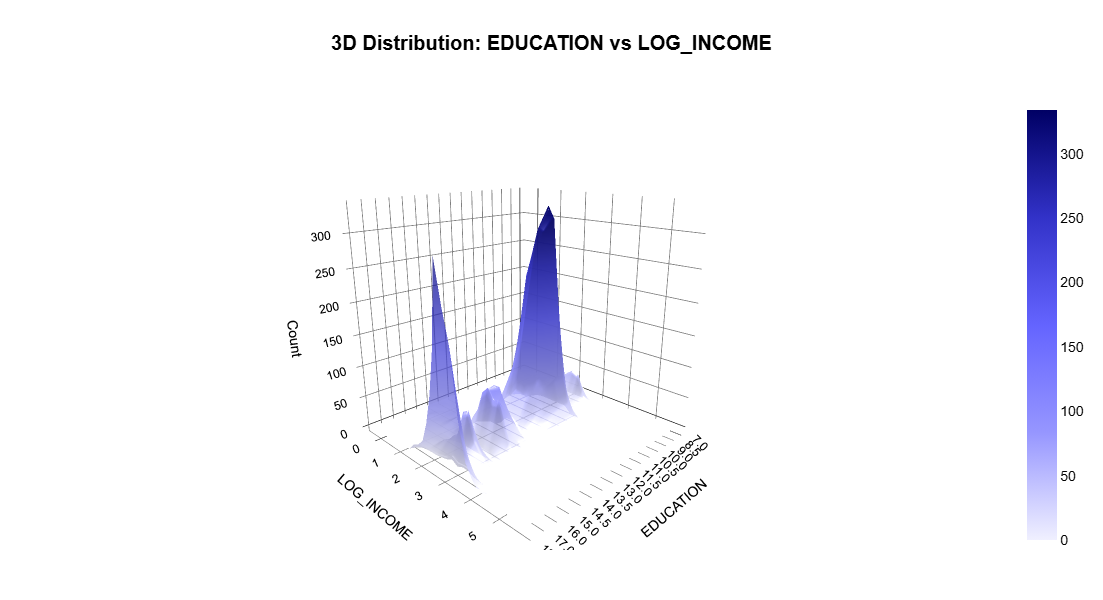

In [8]:
def plot_3d_mountain(df, x_var='EDUCATION', y_var='LOG_INCOME', nbins_y=30):

    x = df[x_var].dropna()
    y = df[y_var].dropna()
    common_idx = x.index.intersection(y.index)
    x = x.loc[common_idx]
    y = y.loc[common_idx]
    
    # Encode EDUCATION
    if not np.issubdtype(x.dtype, np.number):
        x_encoded, x_uniques = pd.factorize(x)
    else:
        x_encoded = x.values
        x_uniques = np.unique(x)
    
    # 2D histogram
    hist, xedges, yedges = np.histogram2d(x_encoded, y, bins=[len(x_uniques), nbins_y])
    hist = hist.astype(float)
    x_centers = np.arange(len(x_uniques))
    y_centers = 0.5 * (yedges[1:] + yedges[:-1])

    print("Min count:", np.min(hist), "Max count:", np.max(hist))


    custom_colorscale = [
        [0.0, 'rgb(240, 240, 255)'],  # Light base
        [0.25, 'rgb(150, 150, 255)'],
        [0.5, 'rgb(100, 100, 255)'],
        [0.75, 'rgb(50, 50, 200)'],
        [1.0, 'rgb(0, 0, 100)']       # Dark peak
    ]


    fig = go.Figure(data=[
        go.Surface(
            z=hist.T,
            x=x_centers,
            y=y_centers,
            colorscale=custom_colorscale,
            showscale=True,
            cmin=0,
            cmax=np.max(hist) if np.max(hist) > 0 else 1,
            opacity=0.85,
            lighting=dict(
                ambient=0.8,
                diffuse=0.9,
                specular=0.5,
                roughness=0.5,
                fresnel=0.5
            ),
            hovertemplate=f'{x_var}: %{{x}}<br>{y_var}: %{{y}}<br>Count: %{{z}}<extra></extra>'
        )
    ])

    # Update layout
    fig.update_layout(
        title=dict(
            text=f"<b>3D Distribution: {x_var} vs {y_var}</b>",
            font=dict(size=20),
            x=0.5,
            xanchor='center'
        ),
        scene=dict(
            xaxis_title=x_var,
            yaxis_title=y_var,
            zaxis_title='Count',
            xaxis=dict(
                tickmode='array',
                tickvals=x_centers,
                ticktext=[str(val)[:15] for val in x_uniques], 
                tickangle=45,
                backgroundcolor='rgba(230, 230, 230, 0.5)',
                gridcolor='gray',
                showbackground=True,
                zerolinecolor='black',
                color='black',
                titlefont=dict(size=14),
                tickfont=dict(size=12)
            ),
            yaxis=dict(
                backgroundcolor='rgba(230, 230, 230, 0.5)',
                gridcolor='gray',
                showbackground=True,
                zerolinecolor='black',
                color='black',
                titlefont=dict(size=14),
                tickfont=dict(size=12)
            ),
            zaxis=dict(
                backgroundcolor='rgba(230, 230, 230, 0.5)',
                gridcolor='gray',
                showbackground=True,
                zerolinecolor='black',
                color='black',
                titlefont=dict(size=14),
                tickfont=dict(size=12)
            ),
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=0.7)  
            )
        ),
        font=dict(family="Arial", color="black", size=14),
        paper_bgcolor='white',
        plot_bgcolor='white',
        width=800,
        height=600,
        margin=dict(l=50, r=50, t=100, b=50),
        showlegend=False
    )

    fig.show()


plot_3d_mountain(df)

# Distribution and box plots

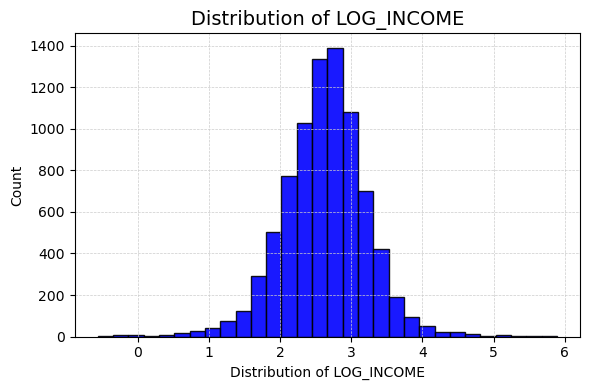

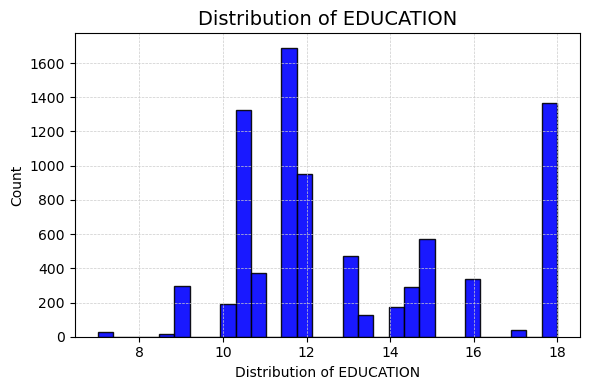

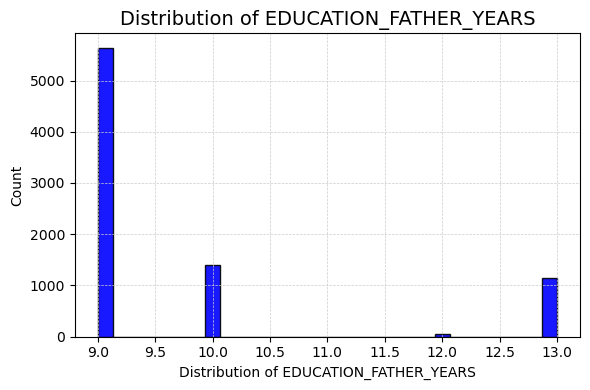

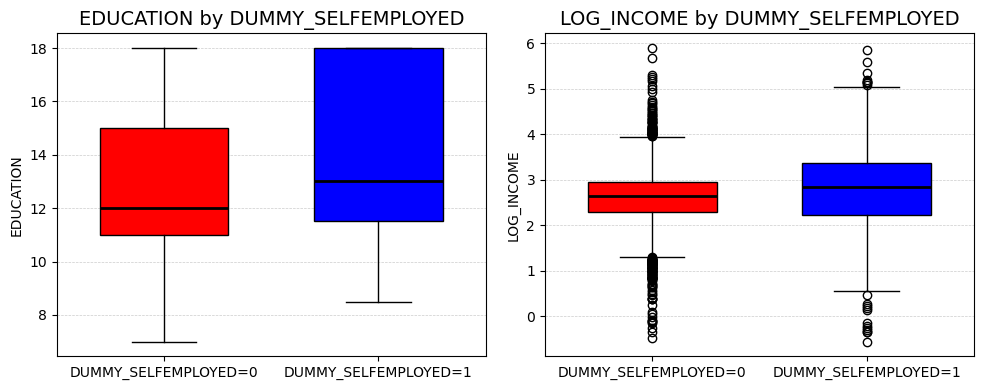

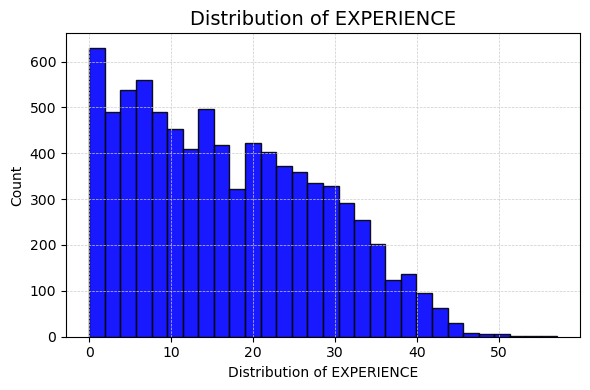

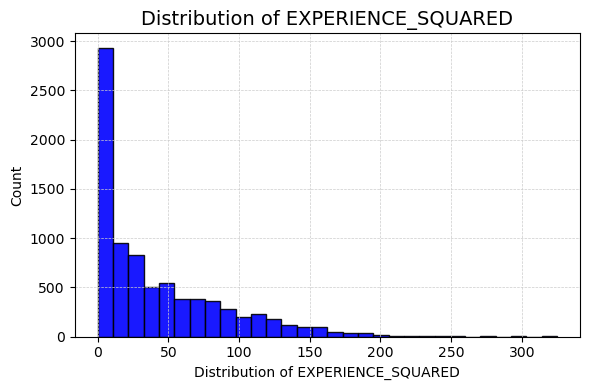

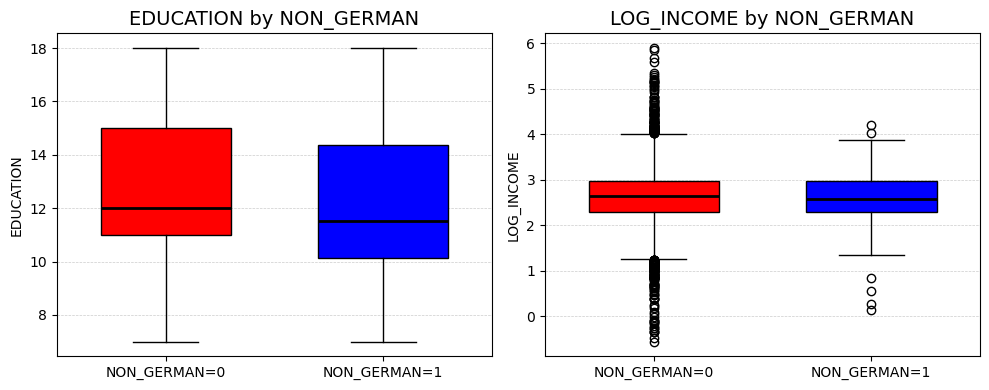

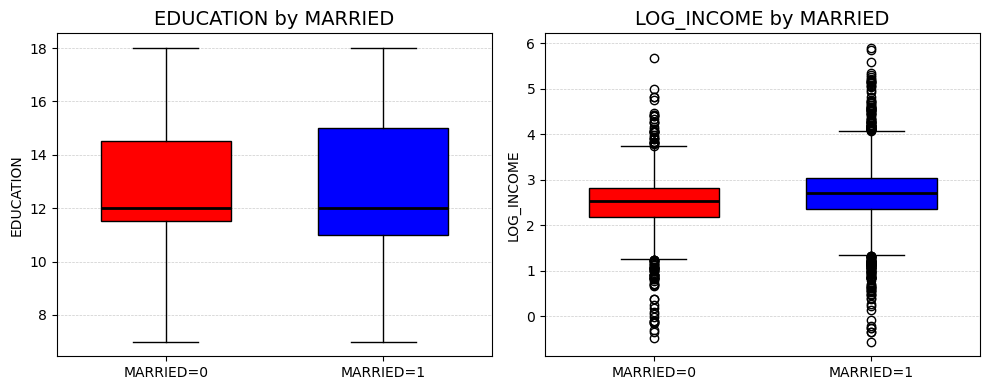

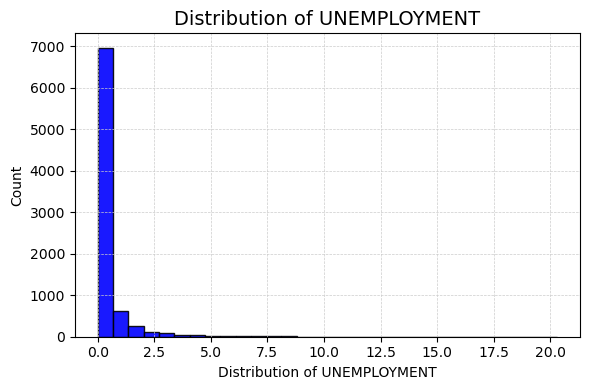

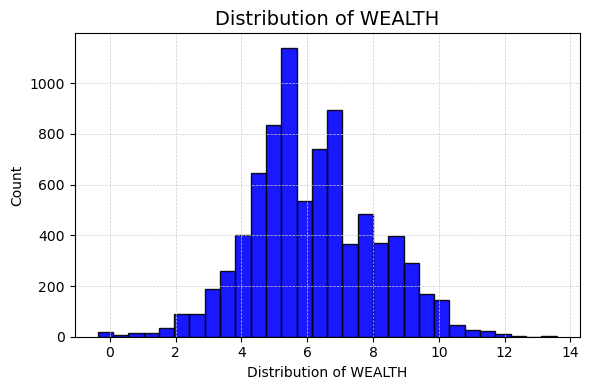

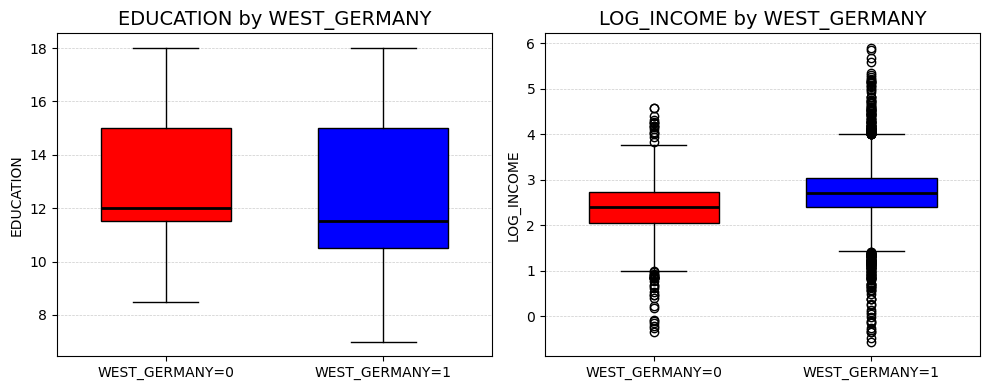

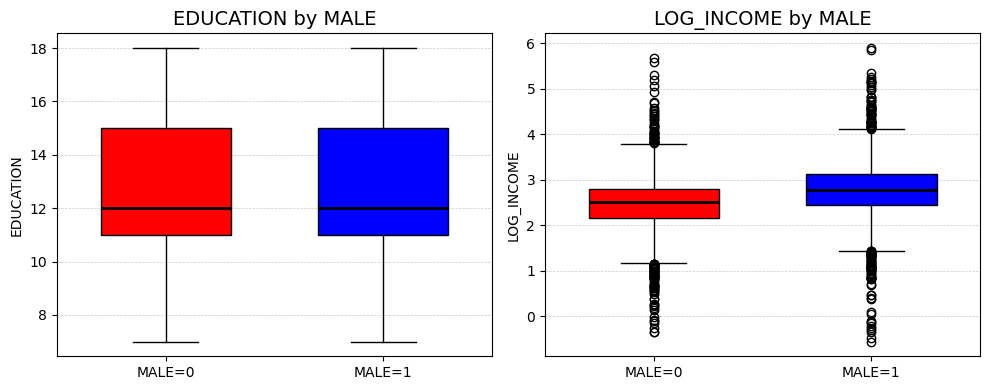

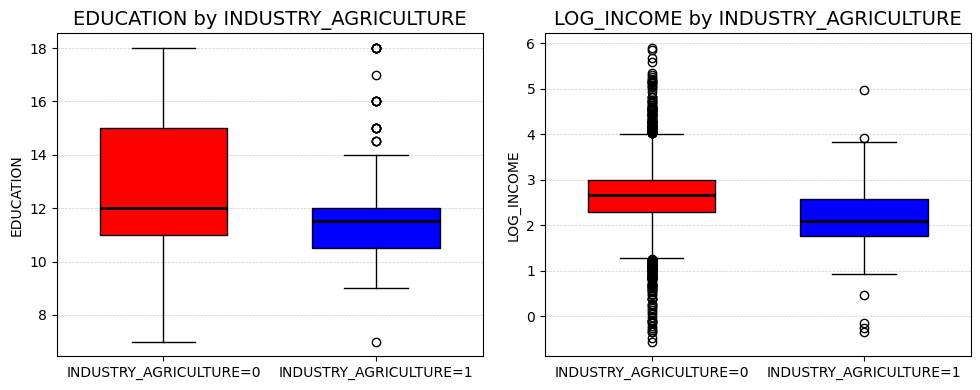

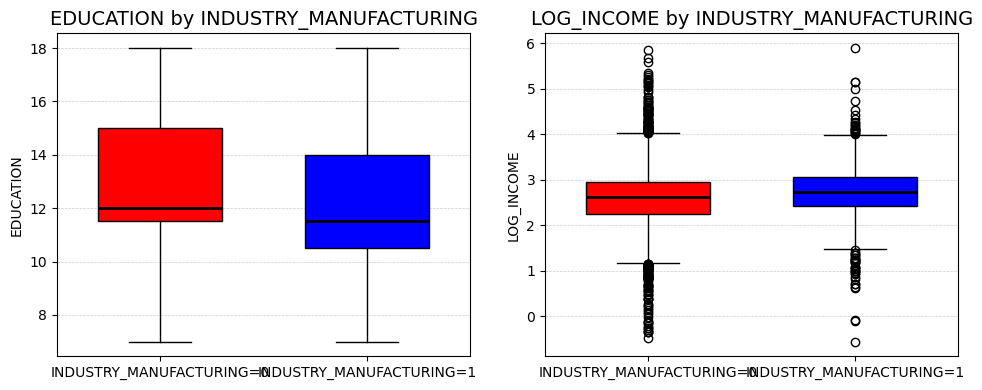

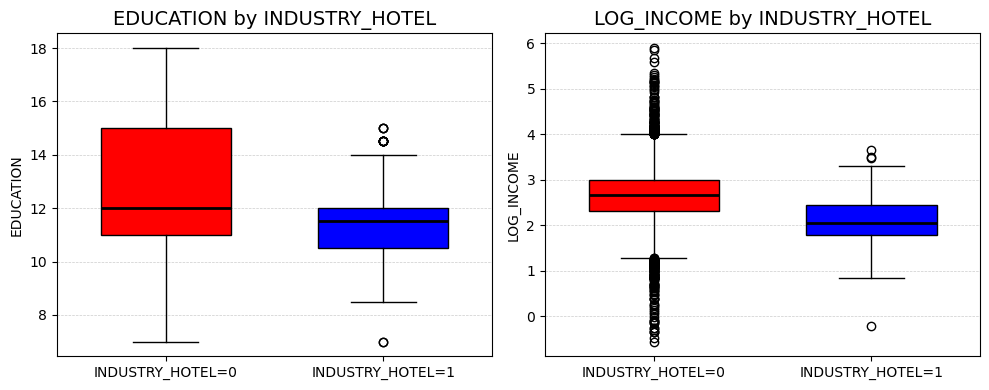

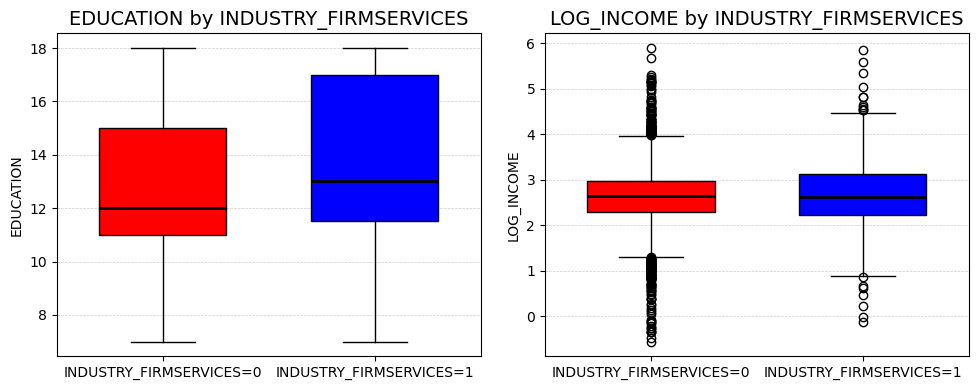

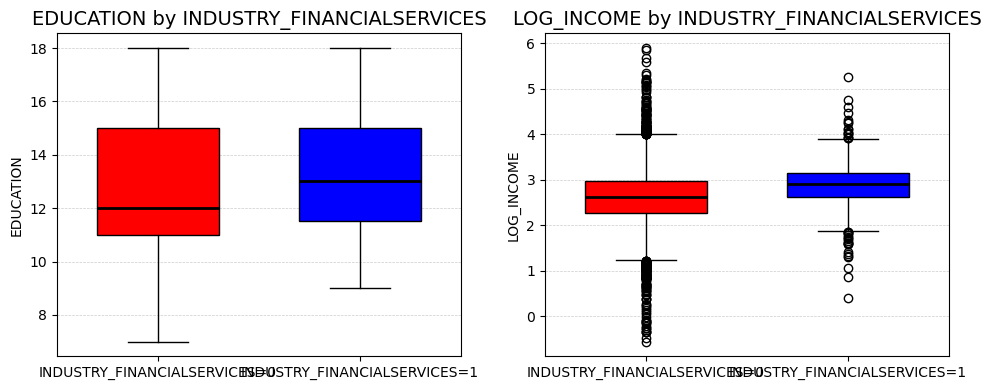

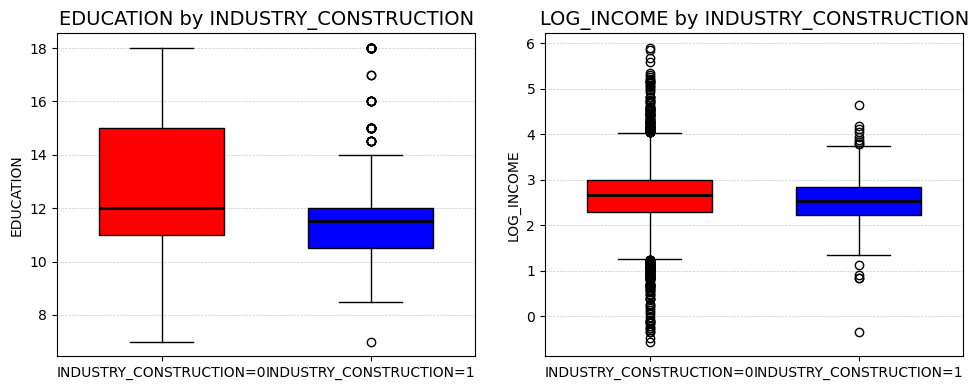

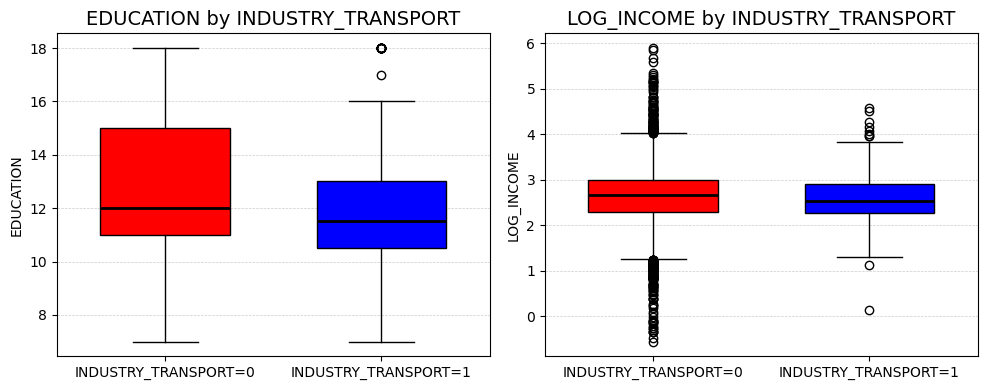

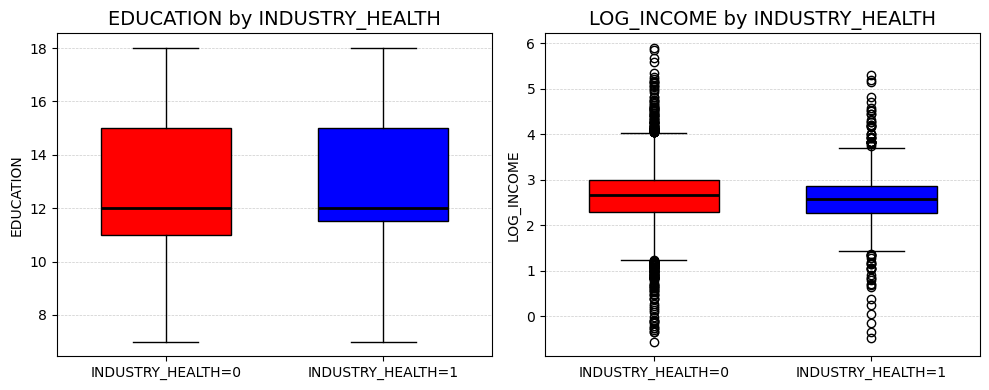

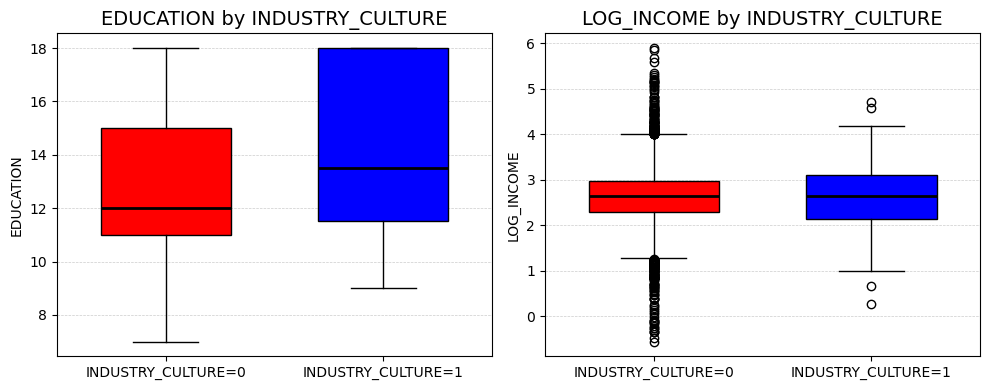

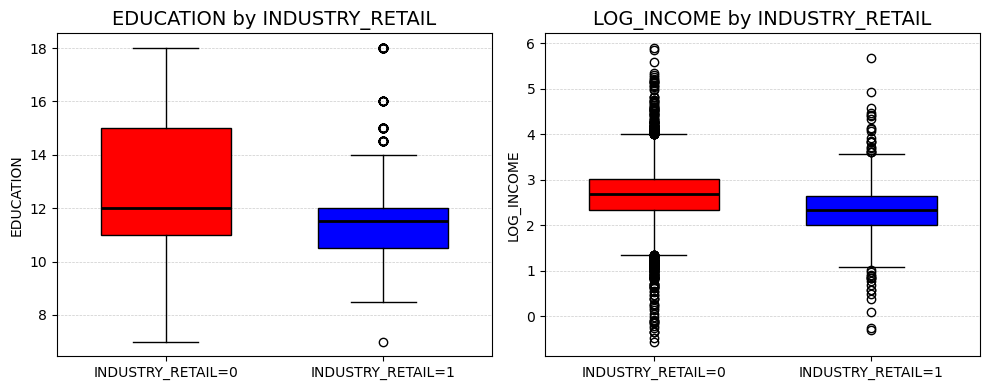

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_binary_boxplot(ax, df, col, outcome):
    grp0 = df.loc[df[col] == 0, outcome].dropna()
    grp1 = df.loc[df[col] == 1, outcome].dropna()

    # box for group 0 at x=1
    ax.boxplot(
        grp0,
        positions=[1],
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor='red', edgecolor='k'),
        medianprops=dict(color='k', linewidth=2)
    )
    # box for group 1 at x=2
    ax.boxplot(
        grp1,
        positions=[2],
        widths=0.6,
        patch_artist=True,
        boxprops=dict(facecolor='blue', edgecolor='k'),
        medianprops=dict(color='k', linewidth=2)
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels([f'{col}=0', f'{col}=1'])
    ax.set_ylabel(outcome)
    ax.set_title(f'{outcome} by {col}', fontsize=14)
    ax.grid(color='0.8', linestyle='--', linewidth=0.5, axis='y')


def plot_numeric_histogram(ax, series, title):
    ax.hist(series.dropna(), bins=30, color='blue', edgecolor='k', alpha=0.9)
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(title)
    ax.set_ylabel('Count')
    ax.grid(color='0.8', linestyle='--', linewidth=0.5)


def overview_plots(df):
    num_cols = df.select_dtypes(include='number').columns
    for col in num_cols:
        vals = set(df[col].dropna().unique())
        if vals <= {0, 1}:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            plot_binary_boxplot(axes[0], df, col, 'EDUCATION')
            plot_binary_boxplot(axes[1], df, col, 'LOG_INCOME')
            fig.tight_layout()
            plt.show()
        else:
            fig, ax = plt.subplots(figsize=(6, 4))
            plot_numeric_histogram(ax, df[col], f'Distribution of {col}')
            fig.tight_layout()
            plt.show()


overview_plots(df)


# Correlation Heatmap

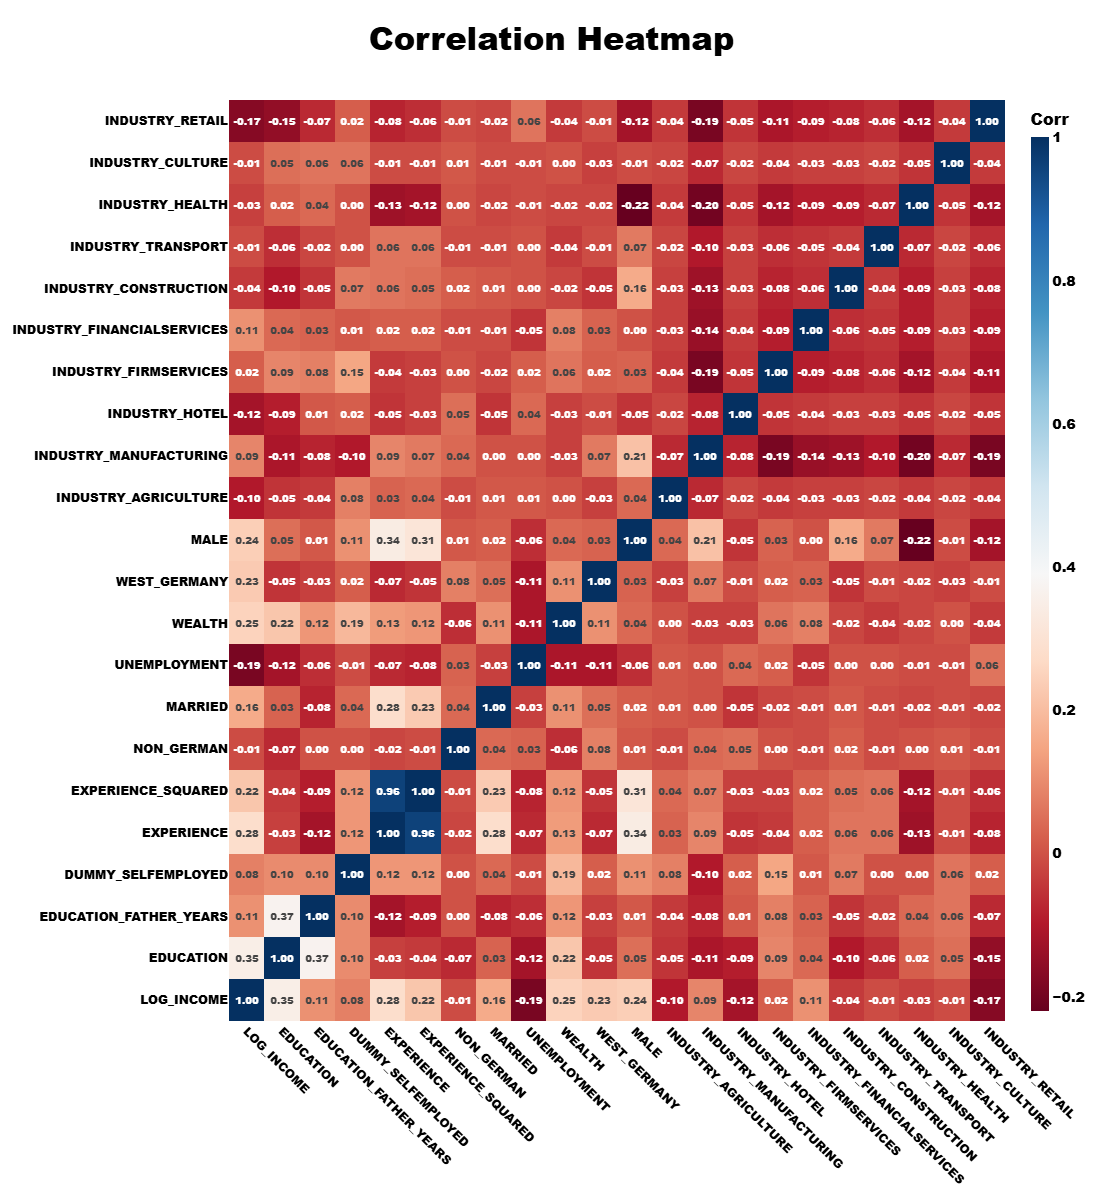

In [28]:
import plotly.express as px
numeric_cols = df.select_dtypes(include='number').columns
def plot_correlation_heatmap(df, numeric_cols, title="Correlation Heatmap"):
    corr = df[numeric_cols].corr().round(2)
    fig = px.imshow(
        corr,
        text_auto='.2f',
        color_continuous_scale='RdBu',
        origin='lower',
        aspect='auto',
        title=title,
        width=1400,   # Even bigger
        height=1200
    )
    fig.update_layout(
        font=dict(family="Arial Black", color="black", size=20),  # For numbers in matrix
        title=dict(font=dict(size=32, color='black', family="Arial Black"), x=0.5),
        paper_bgcolor='white',
        plot_bgcolor='white',
        margin=dict(l=60, r=60, t=100, b=60),
        coloraxis_colorbar=dict(
            title="Corr",
            thickness=18,   # thinner colorbar
            tickfont=dict(size=14),
            titlefont=dict(size=16)
        )
    )
    fig.update_xaxes(
        tickangle=45,
        tickfont=dict(size=12, color='black'),  # Smaller axis text
        title_font=dict(size=16)
    )
    fig.update_yaxes(
        tickfont=dict(size=12, color='black'),  # Smaller axis text
        title_font=dict(size=16)
    )
    fig.show()


plot_correlation_heatmap(df, numeric_cols)

# 95% Confidence Interval

In [31]:
def compute_95_interval(mean_array, var_array):
    """
    Compute the 95% confidence interval for each element in the arrays.
    
    Parameters:
        mean_array (np.ndarray): Array of means.
        var_array (np.ndarray): Array of variances.
    
    Returns:
        lower (np.ndarray): Lower bounds of the 95% intervals.
        upper (np.ndarray): Upper bounds of the 95% intervals.
    """
    std_array = np.sqrt(var_array)
    lower = mean_array - 1.96 * std_array
    upper = mean_array + 1.96 * std_array
    return lower, upper

# GIBBS Sampling

In [34]:
def bayesian_gibbs_sampler(data, y_tilde_beta, total_samples=11000, warmup_period=1000):
    """
    A Bayesian Gibbs sampler for estimating the effect of education on income.
    Returns: All samples, plus control and instrument variable names.
    """
    import numpy as np
    import random
    from scipy.stats import wishart, multivariate_normal
    import tqdm

    # Extract variables from the data frame
    log_income = data.iloc[:, 0] # y: log(income), shape (n,)
    education = data.iloc[:, 1].astype(float) # X: years of education, shape (n,)
    father_education = data.iloc[:, 2] # Z: father's education, shape (n,)

    num_observations = data.shape[0] #8244
    num_columns = data.shape[1] #28

    ones_vector = np.ones((num_observations, 1)) #column of ones
    control_matrix = np.hstack((data.iloc[:, 3:num_columns], ones_vector)) #8244x28 [controls | constant]
    num_controls = control_matrix.shape[1] #28

    # Build the instrument matrix Z by horizontally stacking:
    #8244x29 [father_education  (1) ∣ controls (27) ∣ constant (1) ] or [X_hat | w_1 ... w_27 | 1]
    instrument_matrix = np.hstack((father_education.values.reshape(-1, 1), control_matrix)).astype(float)
    num_instruments = instrument_matrix.shape[1] #29

    # Get variable names
    control_var_names = list(data.columns[3:]) + ['const'] #controls + const
    instrument_var_names = ['father_education'] + control_var_names 

    # Initial values for Gibbs sampling
    
    # 1st‐stage OLS: regress education on [instruments | controls]:
    #education_i = δ_z · father_education_i + Σ_j δ_wj · w_ij + δ_const + u_2i
    education_coefficients_initial = np.linalg.lstsq(instrument_matrix, education, rcond=None)[0]
    
    # Fitted values from 1st‐stage regression:
    #\hat{education}_i = δ̂_z · father_education_i + Σ_j δ̂_wj · w_ij + δ̂_const
    predicted_education = instrument_matrix.dot(education_coefficients_initial)

    # Build the 2nd‐stage design matrix for regression:
    #   [ \hat{education}_i, w_i1, w_i2, ..., w_i,k ] 
    # corresponding to the model
    #   log_income_i = β·\hat{education}_i + Σ_{j=1}^k γ_j·w_ij + u_i
    second_stage_matrix = np.hstack((predicted_education.reshape(-1, 1), control_matrix))

    # Initial 2nd‐stage OLS regression:
    #   [β̂_initial, γ̂_initial] = argmin || log_income - [\hat{education}, W] · [β, γ] ||^2
    # i.e. OLS estimates for 
    #   log_income_i = β_initial · \hat{education}_i + Σ_{j=1}^k γ_initial_j · w_ij + residual_i
    income_coefficients_initial = np.linalg.lstsq(second_stage_matrix, log_income, rcond=None)[0]
    
    education_effect_initial = income_coefficients_initial[0]  # picks off β̂_initial, the estimated effect of predicted education on log(income)
    control_effects_initial = income_coefficients_initial[1:] # picks off [γ̂_1_initial, γ̂_2_initial, …, γ̂_{num_controls}_initial], the estimated effects of each control
    
    income_residuals = log_income - second_stage_matrix.dot(income_coefficients_initial) #   û₁ = y - ŷ   where ŷ = second_stage_matrix @ income_coefficients_initial
    education_residuals = education - instrument_matrix.dot(education_coefficients_initial) #   û₂ = x - x̂   where x̂ = instrument_matrix @ education_coefficients_initial
    
    
    #[ Var(û₁), Cov(û₁, û₂) ],
    #[ Cov(û₂, û₁), Var(û₂)]
    residual_covariance_initial = np.cov(np.vstack((income_residuals, education_residuals)))

    education_effect = education_effect_initial # ← initial estimate β̂OLS from the second-stage regression
    control_effects = control_effects_initial # ← initial estimates [δ̂₁, …, δ̂ₖ] from the second-stage regression
    instrument_coefficients = education_coefficients_initial # ← initial estimates [γ̂₀, γ̂₁, …, γ̂ₘ] from the first-stage regression
    residual_covariance = residual_covariance_initial # ← initial 2×2 covariance of [û₁, û₂] from the OLS residuals
    residual_precision = np.linalg.inv(residual_covariance_initial) # ← inverse of that 2×2 covariance matrix

    education_effect_samples = np.zeros((total_samples, 1)) # ← storage for β draws (total_samples × 1)
    control_effect_samples = np.zeros((total_samples, num_controls)) # ← storage for δ draws (total_samples × num_controls)
    instrument_coefficient_samples = np.zeros((total_samples, num_instruments)) # ← storage for γ draws (total_samples × num_instruments)
    covariance_samples = np.zeros((total_samples, 4))# ← storage for Σᵤ draws (total_samples × 4, since Σᵤ is 2×2 flattened)

    education_effect_conditional_mean = np.zeros((total_samples, 1)) # ← E[β | rest] draws (total_samples × 1)
    education_effect_conditional_variance = np.zeros((total_samples, 1)) #  ← Var[β | rest] draws (total_samples × 1)

    # Precompute (Z′Z)⁻¹ once as it will be used repeatedly when sampling γ
    #instrument_gram_inverse  ← inverse of the Gram matrix Z′Z (num_instruments × num_instruments)
    instrument_gram_inverse = np.linalg.inv(np.dot(instrument_matrix.T, instrument_matrix))

    education_effect_prior_mean = 0
    education_effect_prior_precision = 1

    for iteration in tqdm.tqdm(range(total_samples), desc='Gibbs sampling'):
        # Flatten the instrument coefficients array from a (n×1) column vector into a 1-D array of length n
        instrument_coefficients = instrument_coefficients.flatten()

        # u₁ = y – X̂β – Wδ in the two‐stage setup.
        income_residuals = log_income - (education + father_education * y_tilde_beta) * education_effect - control_matrix.dot(control_effects)
        
        #u₂ = X – Zδ in the two‐stage setup.
        education_residuals = education - instrument_matrix.dot(instrument_coefficients)  
        residual_matrix = np.hstack((income_residuals.values.reshape(-1, 1), education_residuals.values.reshape(-1, 1))) #   [ u₁   u₂ ]
        wishart_scale_matrix = np.linalg.inv(residual_matrix.T @ residual_matrix) #   S = (U'U)⁻¹ where U = residual_matrix.

        # Draw a random precision matrix Σ⁻¹ from a Wishart distribution
        residual_precision = wishart.rvs(df=num_observations, scale=wishart_scale_matrix) 
        residual_covariance = np.linalg.inv(residual_precision)

        # Columns: [ (education + father_education * y_tilde_beta) , controls... , constant ]
        explanatory_matrix = np.hstack((((education + father_education * y_tilde_beta).values.reshape(-1, 1)), control_matrix))

        #   E[u₁ | u₂] = (u₂ * Cov₁₂) / Var₂₂
        # where Cov₁₂ = residual_covariance[0,1], Var₂₂ = residual_covariance[1,1].
        conditional_mean_income = (education - instrument_matrix.dot(instrument_coefficients)) * residual_covariance[0, 1] / residual_covariance[1, 1]

        #   Var(u₁ | u₂) = Var₁₁ − Cov₁₂² / Var₂₂
        conditional_variance_income = residual_covariance[0, 0] - (residual_covariance[0, 1]**2) / residual_covariance[1, 1]
        
        effect_precision = np.zeros((1 + num_controls, 1 + num_controls)) # Initialize the posterior precision matrix for [β, δ₁...] coefficients.
        effect_precision[0, 0] = education_effect_prior_precision # Add the prior precision for β (on the diagonal entry corresponding to β).
        effect_precision += (1 / conditional_variance_income) * np.dot(explanatory_matrix.T, explanatory_matrix) #   (1 / Var(u₁|u₂)) * X'X
        
        effect_covariance = np.linalg.inv(effect_precision) 
        effect_covariance = (effect_covariance + effect_covariance.T) * 0.5 # Symmetrize to correct for any numerical asymmetry

        
        effect_mean_numerator = np.zeros((1 + num_controls, 1)) # Compute the numerator of the posterior mean for [β, δ₁...] coefficients
        # Add the prior contribution for β: prior_precision × prior_mean
        effect_mean_numerator[0, 0] = education_effect_prior_precision * education_effect_prior_mean

        #   (1 / Var(u₁|u₂)) * X' * (y − E[u₁|u₂])
        effect_mean_numerator += (1 / conditional_variance_income) * explanatory_matrix.T @ (log_income - conditional_mean_income).values.reshape(-1, 1)
        effect_mean = np.dot(effect_covariance, effect_mean_numerator)  # Obtain the posterior mean vector by multiplying posterior covariance

        # Draw a sample for [β, δ₁...] jointly from the multivariate normal posterior
        effect_sample = multivariate_normal.rvs(mean=effect_mean.flatten(), cov=effect_covariance).reshape(-1, 1)
        education_effect = effect_sample[0, 0] # Extract the sampled β (education effect) from the first element
        control_effects = effect_sample[1:, 0] # Extract the sampled control effects δ₁…δₖ from the remaining elements
        
        education_effect_conditional_mean[iteration, 0] = effect_mean[0, 0] # effect_mean[0,0] is the posterior mean for β,
        education_effect_conditional_variance[iteration, 0] = effect_covariance[0, 0]  # effect_covariance[0,0] is the posterior variance for β.

        # Compute conditional posterior mean of education (X) given current β, δ₁, Σ_u:
        # (log_income − (education + father_education*y_tilde_beta)*β − W·δ₁) * Cov(u₁,u₂)/Var(u₁)
        conditional_mean_education = (log_income - (education + father_education * y_tilde_beta) * education_effect - 
                                      control_matrix.dot(control_effects)) * residual_covariance[0, 1] / residual_covariance[0, 0]
        conditional_variance_education = residual_covariance[1, 1] - (residual_covariance[0, 1]**2) / residual_covariance[0, 0]  # Var(u₂) − Cov(u₁,u₂)²/Var(u₁)
        
        instrument_covariance = conditional_variance_education * instrument_gram_inverse # = conditional_variance_education * (Z'Z)^{-1}
        instrument_covariance = (instrument_covariance + instrument_covariance.T) * 0.5 # Symmetrize to avoid numerical asymmetry

        # Posterior mean numerator for δ₂:
        # (1/Var(u₂|...)) * Z' (education − E[education|...])
        instrument_mean_numerator = (1 / conditional_variance_education) * np.dot(instrument_matrix.T, (education - conditional_mean_education))
        instrument_mean = np.dot(instrument_covariance, instrument_mean_numerator)

        # Draw δ₂ from its multivariate normal posterior
        instrument_coefficients = multivariate_normal.rvs(mean=instrument_mean.flatten(), cov=instrument_covariance).reshape(-1, 1)

        # Store this iteration's draws
        education_effect_samples[iteration, 0] = education_effect
        control_effect_samples[iteration, :] = control_effects.flatten()
        instrument_coefficient_samples[iteration, :] = instrument_coefficients.flatten()

         # Flatten 2×2 covariance Σ_u into a length-4 vector: [σ₁₁, σ₁₂, σ₂₁, σ₂₂]
        covariance_samples[iteration, :] = np.concatenate((residual_covariance[0, 0:2], residual_covariance[1, 0:2]))
       
    # Return all the samples and variable names
    return (education_effect_samples, # draws for β
            control_effect_samples,   # draws for control effects δ₁
            instrument_coefficient_samples,   # draws for instrument effects δ₂
            covariance_samples,      # draws for Σₙ flattened
            education_effect_conditional_mean,  # β's conditional posterior mean per draw
            education_effect_conditional_variance,  # β's conditional posterior variance per draw
            control_var_names, # names of the control variables + 'const'
            instrument_var_names)   # names of instruments + control names

# Transforming GIBBS sampling into dataframes

In [36]:
def analyze_mcmc_posterior(
    education_effect_samples, control_effect_samples, 
    instrument_coefficient_samples, covariance_samples, warmup_period,
    control_var_names=None, instrument_var_names=None):
    """
    Analyzes and visualizes the results from Bayesian MCMC sampling.
    Returns: Summary DataFrames with row/column names for education, control, and instrument variables.

    """
    #1. Discard the warmup draws
    #    We assume samples indexed 0..warmup_period are burn-in
    post_warmup_education_effect = education_effect_samples[(warmup_period+1):]
    post_warmup_control_effects = control_effect_samples[(warmup_period+1):, :]
    post_warmup_instrument_coeffs = instrument_coefficient_samples[(warmup_period+1):, :]
    post_warmup_covariance = covariance_samples[(warmup_period+1):, :]

    # 2. Extract variance/covariance components from the 2×2 Σ draws
    # covariance_samples columns: [Var(income), Cov(income,edu), Cov(edu,income), Var(edu)]
    variance_income = post_warmup_covariance[:, 0]
    covariance_term = post_warmup_covariance[:, 1]
    variance_education = post_warmup_covariance[:, 3]

    #Compute posterior draws of the correlation between income and education residuals 
    # Corr(u_income, u_education) = Cov(u₁,u₂) / sqrt[Var(u₁)·Var(u₂)]
    correlation_coefficient = covariance_term / np.sqrt(variance_income * variance_education)

    num_post_warmup_samples = post_warmup_education_effect.shape[0]

    # 3. Combine β (education effect) and δ₁ (control effects) for joint summaries
    combined_effects = np.concatenate((post_warmup_education_effect, post_warmup_control_effects), axis=1)  # shape: (num_draws, 1 + num_controls)
    
    sorted_combined_effects = np.sort(combined_effects, axis=0)
    
    # 4. Compute summary statistics: mean, std, and selected quantiles
    percentiles = [2.5, 97.5, 25, 75]
    quantile_indices = [int(p/100 * num_post_warmup_samples) for p in percentiles]
    summary_statistics = np.vstack([
        np.mean(combined_effects, axis=0),
        np.std(combined_effects, axis=0),
        sorted_combined_effects[quantile_indices[0], :],  # 2.5%
        sorted_combined_effects[quantile_indices[1], :],  # 97.5%
        sorted_combined_effects[quantile_indices[2], :],  # 25%
        sorted_combined_effects[quantile_indices[3], :]   # 75%
    ]) # shape: (6, 1 + num_controls)

    # 5. Label rows and columns for the education+control summary
    row_names = ['Mean', 'Std Dev', '2.5% Quantile', '97.5% Quantile', '25% Quantile', '75% Quantile']
    if control_var_names is not None:
        col_names = ['Education Effect'] + control_var_names
    else:
        col_names = ['Education Effect'] + [f'Control {i+1}' for i in range(control_effect_samples.shape[1])]
    summary_df = pd.DataFrame(summary_statistics, index=row_names, columns=col_names)

    # 6. Prepare summary for the instrument coefficients δ₂
    sorted_instr = np.sort(post_warmup_instrument_coeffs, axis=0)
    instrument_summary_statistics = np.vstack([
        np.mean(post_warmup_instrument_coeffs, axis=0),
        np.std(post_warmup_instrument_coeffs, axis=0),
        sorted_instr[quantile_indices[0], :],  # 2.5%
        sorted_instr[quantile_indices[1], :],  # 97.5%
        sorted_instr[quantile_indices[2], :],  # 25%
        sorted_instr[quantile_indices[3], :]   # 75%
    ])
    if instrument_var_names is not None:
        instr_col_names = instrument_var_names
    else:
        instr_col_names = [f'Instrument {i+1}' for i in range(post_warmup_instrument_coeffs.shape[1])]
    instrument_summary_df = pd.DataFrame(instrument_summary_statistics, index=row_names, columns=instr_col_names)

    return summary_df, instrument_summary_df

# Posterior results of the instrumental variables model for a perfectly valid instrument

In [38]:
# Load the German dataset
# ------------------------------
print("Loading the German dataset...")
dataset = pd.read_excel(r"C:\School\THESIS\Cross-sectional\German_data_2004_names_of_columns.xls", header=0)

# Set parameters for the Bayesian analysis
# ----------------------------------------------
print("Setting up Bayesian analysis parameters...")

father_education_coefficient = 0 # γ̃ :assumed direct effect of father's education on income
total_samples = 11000 # Total Gibbs iterations (including warmup)
warmup_period = 1000 # Number of initial draws to discard as burn-in

# Run the Bayesian Gibbs sampler
# ------------------------------------
print(f"Running Bayesian Gibbs sampler with {total_samples} samples (including {warmup_period} warmup samples)...")
print("This may take several minutes...")

(
    education_effect_samples, # shape (total_samples, 1): draws of β (education effect)
    control_effect_samples, # shape (total_samples, num_controls): draws of control coefficients
    instrument_coefficient_samples, # shape (total_samples, num_instruments): draws of instrument coefficients δ’s
    covariance_samples, # shape (total_samples, 4): draws of flattened 2×2 covariance matrix Σ_u
    education_conditional_mean, # shape (total_samples, 1): conditional posterior means of β at each iteration μ_cond(s) = E[β | rest, γ̃]
    education_conditional_var, # shape (total_samples, 1): conditional posterior variances of β
    control_var_names, # list of control variable names + ['const']
    instrument_var_names # list of instrument names + control names + ['const']
) = bayesian_gibbs_sampler(dataset, father_education_coefficient, total_samples, warmup_period)

# Analyze the posterior distributions
# ---------------------------------------
print("Analyzing posterior distributions and creating visualizations...")

summary_df, instrument_summary_df = analyze_mcmc_posterior(
    education_effect_samples,
    control_effect_samples,
    instrument_coefficient_samples,
    covariance_samples,
    warmup_period,
    control_var_names=control_var_names,
    instrument_var_names=instrument_var_names
)

# Print nicely
print("\n=== COMPREHENSIVE SUMMARY STATISTICS (Education + Controls) ===")
print(summary_df)
print("\n=== COMPREHENSIVE SUMMARY STATISTICS (Instruments) ===")
print(instrument_summary_df)

# Save results to file
# ------------------------------------
#print("Saving results to file...")

#summary_df.T.to_csv('bayesian_analysis_results.csv')
#instrument_summary_df.T.to_csv('bayesian_instrument_results.csv')

#print("Results saved to 'bayesian_analysis_results.csv' and 'bayesian_instrument_results.csv'")

Loading the German dataset...
Setting up Bayesian analysis parameters...
Running Bayesian Gibbs sampler with 11000 samples (including 1000 warmup samples)...
This may take several minutes...


Gibbs sampling: 100%|██████████| 11000/11000 [02:18<00:00, 79.24it/s]


Analyzing posterior distributions and creating visualizations...

=== COMPREHENSIVE SUMMARY STATISTICS (Education + Controls) ===
                Education Effect  DUMMY_SELFEMPLOYED  EXPERIENCE  \
Mean                    0.078787            0.001742    0.034258   
Std Dev                 0.006516            0.019151    0.001663   
2.5% Quantile           0.066175           -0.035960    0.030962   
97.5% Quantile          0.091427            0.039067    0.037455   
25% Quantile            0.074394           -0.011076    0.033121   
75% Quantile            0.083199            0.014663    0.035382   

                EXPERIENCE_SQUARED  NON_GERMAN   MARRIED  UNEMPLOYMENT  \
Mean                     -0.005780    0.032914  0.051307     -0.048998   
Std Dev                   0.000407    0.032177  0.012185      0.005470   
2.5% Quantile            -0.006563   -0.029750  0.027574     -0.059574   
97.5% Quantile           -0.004982    0.095982  0.075074     -0.038001   
25% Quantile           

# Posterior distribution of β for different values of γ̃ = γ/β (i.e. allowing varying direct effects of father's education)

In [44]:

def gamma_tilde_posterior(gamma_values, dataset, total_samples=11000, warmup_period=1000):
    """
    For each γ̃ (father’s education coefficient), we run the Gibbs sampler
    to obtain draws {β(s)} from the posterior of β = ∂(log income)/∂(education)
    under the assumption γ̃, and then compute summary statistics:
    
      β^(s) ∼ p(β | y, γ̃ )

    where s = B+1 … N index the post–warmup draws.
    """
    results = []
    for father_education_coefficient in gamma_values:
        print(f"Running Bayesian Gibbs sampler with gamma_tilde={father_education_coefficient}...")
        (
            education_effect_samples,
            control_effect_samples,
            instrument_coefficient_samples,
            covariance_samples,
            education_conditional_mean,
            education_conditional_var,
            control_var_names,
            instrument_var_names
        ) = bayesian_gibbs_sampler(dataset, father_education_coefficient, total_samples, warmup_period)

        # Discard warmup draws:   β(s), s = B+1 … N
        post_warmup_education_effect = education_effect_samples[(warmup_period+1):].flatten()

        # Compute summary statistics over the N–B post–warmup draws:
        #μ̂ = (1/(N−B)) ∑ β(s)
        mean = np.mean(post_warmup_education_effect)

        #σ̂ = sqrt((1/(N−B)) ∑ (β(s) − μ̂)²)
        std = np.std(post_warmup_education_effect)

        # Percentiles: solve for p such that fraction p of draws ≤ percentile
        q025 = np.percentile(post_warmup_education_effect, 2.5)
        q975 = np.percentile(post_warmup_education_effect, 97.5)
        q25 = np.percentile(post_warmup_education_effect, 25)
        q75 = np.percentile(post_warmup_education_effect, 75)

        results.append([
            father_education_coefficient, mean, std, q025, q975, q25, q75
        ])

    df = pd.DataFrame(
        results,
        columns=['gamma_tilde', 'Mean', 'Std. dev.', '2.5%', '97.5%', '25%', '75%']
    )
    return df


dataset = pd.read_excel(r"C:\School\THESIS\Cross-sectional\German_data_2004_names_of_columns.xls", header=0)
gamma_values = [
    -0.40, -0.30, -0.20, -0.10, 0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.60, 0.70, 0.80, 0.90, 1, 2, 3, 4, 5, 10, 25, 100, 1000
    ]
posterior_table = gamma_tilde_posterior(gamma_values, dataset)
print(posterior_table)
posterior_table.to_csv('gamma_tilde_posterior_table.csv', index=False)


Running Bayesian Gibbs sampler with gamma_tilde=-0.4...


Gibbs sampling: 100%|██████████| 11000/11000 [02:42<00:00, 67.81it/s] 


Running Bayesian Gibbs sampler with gamma_tilde=-0.3...


Gibbs sampling: 100%|██████████| 11000/11000 [2:24:00<00:00,  1.27it/s] 


Running Bayesian Gibbs sampler with gamma_tilde=-0.2...


...

Running Bayesian Gibbs sampler with gamma_tilde=100...


Gibbs sampling: 100%|██████████| 11000/11000 [02:47<00:00, 65.58it/s] 


Running Bayesian Gibbs sampler with gamma_tilde=1000...


Gibbs sampling: 100%|██████████| 11000/11000 [02:47<00:00, 65.82it/s]


    gamma_tilde      Mean  Std. dev.      2.5%     97.5%       25%       75%
0         -0.40  0.234849   0.020772  0.195323  0.277318  0.220064  0.248413
1         -0.30  0.156389   0.014345  0.131223  0.187080  0.145973  0.165652
2         -0.20  0.119012   0.010097  0.099354  0.139284  0.112292  0.125801
3         -0.10  0.094853   0.007939  0.080347  0.111108  0.089257  0.100110
4          0.00  0.079575   0.006957  0.066199  0.093222  0.074688  0.084385
5          0.05  0.073448   0.006134  0.061661  0.085721  0.069318  0.077575
6          0.10  0.068106   0.005528  0.057190  0.078914  0.064299  0.071869
7          0.15  0.063663   0.005142  0.053473  0.073619  0.060142  0.067244
8          0.20  0.059532   0.004870  0.050241  0.069263  0.056223  0.062792
9          0.25  0.056182   0.004687  0.047135  0.065351  0.053023  0.059357
10         0.30  0.053083   0.004518  0.044469  0.061812  0.049988  0.056160
11         0.35  0.050150   0.004224  0.041762  0.058544  0.047374  0.052940

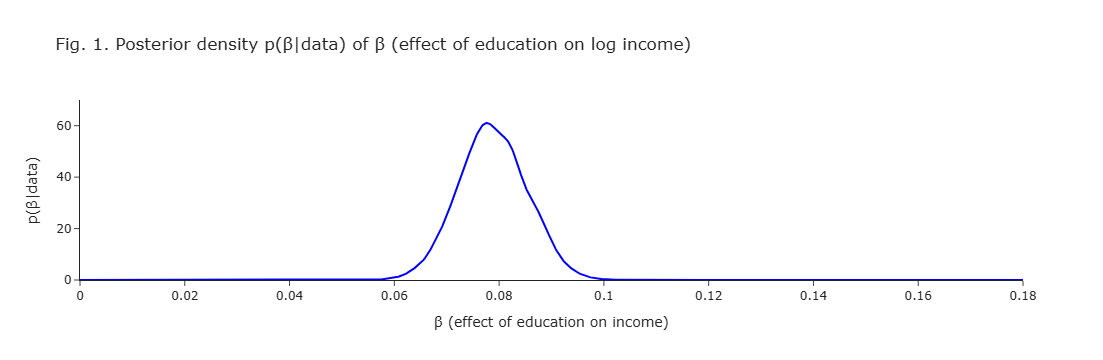

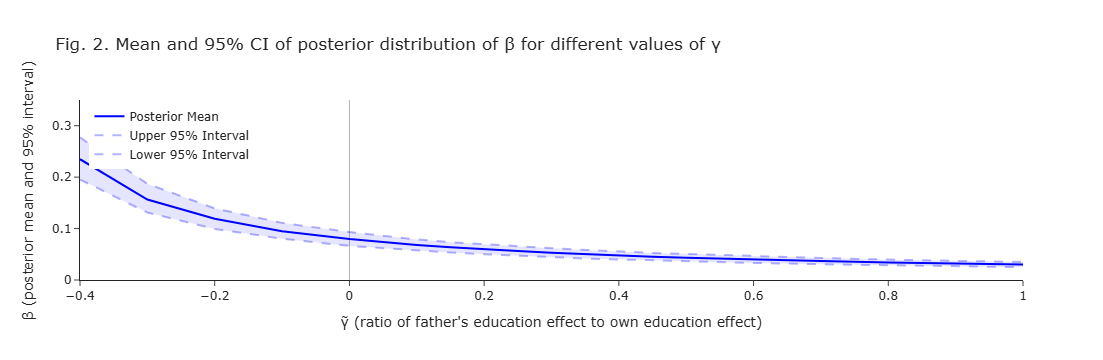

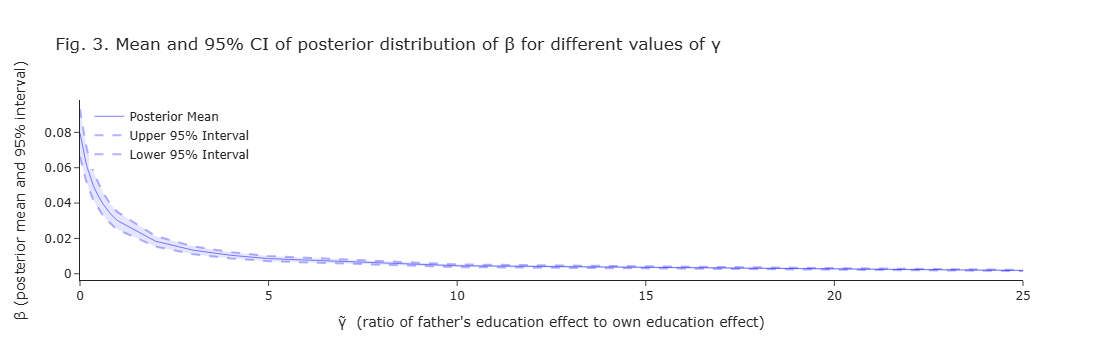

In [49]:
def plot_posterior_figures_plotly(
    education_effect_samples, 
    posterior_table
):
    """
    Creates three figures visualizing how the posterior
    distribution of β (the effect of education on income) behaves:

    Fig. 1: Plots the kernel density estimate of the marginal posterior p(β|data)
             using
               β^(s), s = 1 … S draws from Gibbs sampler.
    Fig. 2: Plots the posterior mean μ̂(β|γ̃) and 95% credible interval
             [q_{2.5%}, q_{97.5%}] versus γ̃ over the range [-0.4, 1.0].
             Here μ̂(β|γ̃) = (1/(S−B)) ∑_{s=B+1}^S β^(s)(γ̃)
    Fig. 3: Same as Fig. 2 but over a larger γ̃ range [0, 25].

    Args:
        education_effect_samples: array of shape (total_samples, 1),
            draws β^(s) from p(β | data, γ̃).
        posterior_table: DataFrame with columns
            ['gamma_tilde', 'Mean', '2.5%', '97.5%', '25%', '75%']
            summarizing each γ̃’s posterior mean and credible bounds.
    """
    import numpy as np
    import plotly.graph_objs as go
    from scipy import stats

    # Figure 1: plot marginal posterior density p(β | data)
    education_effect_flat = education_effect_samples.flatten()
    kde = stats.gaussian_kde(education_effect_flat)
    x_values = np.linspace(0, 0.18, 1000)
    y_values = kde(x_values)
    
    fig1 = go.Figure()
    fig1.add_trace(go.Scatter(
        x=x_values, 
        y=y_values,
        mode='lines',
        line=dict(color='blue', width=2),
        name='Posterior Density'
    ))
    fig1.update_layout(
        title="Fig. 1. Posterior density p(β|data) of β (effect of education on log income)",
        xaxis_title="β (effect of education on income)",
        yaxis_title="p(β|data)",
        xaxis=dict(range=[0, 0.18]),
        yaxis=dict(range=[0, 70]),
        template="simple_white"
    )
    fig1.show()

    # Extract summary from posterior_table:
    #   μ̂ (γ̃ )   = Mean
    #   q_{2.5%}  = lower bound of 95% CI
    #   q_{97.5%} = upper bound of 95% CI
    gamma_tilde = posterior_table['gamma_tilde'].values
    mean = posterior_table['Mean'].values
    upper = posterior_table['97.5%'].values
    lower = posterior_table['2.5%'].values

    # Figure 2: plot μ̂(γ̃) and 95% credible bands for γ̃ ∊ [–0.4, 1.0]
    mask_small = (gamma_tilde >= -0.4) & (gamma_tilde <= 1.0)
    x_small = gamma_tilde[mask_small]
    y1_small = mean[mask_small]
    y2_small = upper[mask_small]
    y3_small = lower[mask_small]

    fig2 = go.Figure()

    # mean curve: μ̂ (γ̃ )
    fig2.add_trace(go.Scatter(
        x=x_small, y=y1_small,
        mode='lines',
        name='Posterior Mean',
        line=dict(color='blue', width=2)
    ))

    # 95% bounds
    fig2.add_trace(go.Scatter(
        x=x_small, y=y2_small,
        mode='lines',
        name='Upper 95% Interval',
        line=dict(color='rgba(0,0,255,0.3)', dash='dash')
    ))
    fig2.add_trace(go.Scatter(
        x=x_small, y=y3_small,
        mode='lines',
        name='Lower 95% Interval',
        line=dict(color='rgba(0,0,255,0.3)', dash='dash')
    ))

    # fill between bounds:
    fig2.add_trace(go.Scatter(
        x=np.concatenate([x_small, x_small[::-1]]),
        y=np.concatenate([y2_small, y3_small[::-1]]),
        fill='toself',
        fillcolor='rgba(0,0,255,0.1)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=False
    ))
    fig2.update_layout(
        title="Fig. 2. Mean and 95% CI of posterior distribution of β for different values of γ",
        xaxis_title="γ̃ (ratio of father's education effect to own education effect)",
        yaxis_title="β (posterior mean and 95% interval)",
        xaxis=dict(range=[-0.4, 1.0]),
        yaxis=dict(range=[0, 0.35]),
        template="simple_white",
        legend=dict(x=0.01, y=0.99)
    )

    # vertical line at γ̃ = 0
    fig2.add_shape(
        type="line",
        x0=0, y0=0,
        x1=0, y1=0.35,
        line=dict(color="black", width=1)
    )
    fig2.show()

    # Figure 3: same for γ̃ ∊ [0, 25]
    mask_large = (gamma_tilde >= 0) & (gamma_tilde <= 25)
    x_large = gamma_tilde[mask_large]
    y1_large = mean[mask_large]
    y2_large = upper[mask_large]
    y3_large = lower[mask_large]

    fig3 = go.Figure()
    fig3.add_trace(go.Scatter(
        x=x_large, y=y1_large,
        mode='lines',
        name='Posterior Mean',
        line=dict(color='blue', width=0.5)
    ))
    fig3.add_trace(go.Scatter(
        x=x_large, y=y2_large,
        mode='lines',
        name='Upper 95% Interval',
        line=dict(color='rgba(0,0,255,0.3)', dash='dash')
    ))
    fig3.add_trace(go.Scatter(
        x=x_large, y=y3_large,
        mode='lines',
        name='Lower 95% Interval',
        line=dict(color='rgba(0,0,255,0.3)', dash='dash')
    ))
    fig3.add_trace(go.Scatter(
        x=np.concatenate([x_large, x_large[::-1]]),
        y=np.concatenate([y2_large, y3_large[::-1]]),
        fill='toself',
        fillcolor='rgba(0,0,255,0.1)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=False
    ))
    fig3.update_layout(
        title="Fig. 3. Mean and 95% CI of posterior distribution of β for different values of γ",
        xaxis_title="γ̃  (ratio of father's education effect to own education effect)",
        yaxis_title="β (posterior mean and 95% interval)",
        xaxis=dict(range=[0, 25]),
        template="simple_white",
        legend=dict(x=0.01, y=0.99)
    )
    fig3.show()

    return fig1, fig2, fig3


fig1, fig2, fig3 = plot_posterior_figures_plotly(education_effect_samples, posterior_table)